# Catalog Creation

Use this notebook to inspect the LWI Region 3 source GeoJSON files, generate the StormHub catalog config, create the base STAC catalog, and then serve the generated catalog with `stormhub-server`.

In [12]:
from pathlib import Path
import json

import geopandas as gpd

from stormhub.logger import initialize_logger
from stormhub.met.storm_catalog import new_catalog

# If this cell fails, adjust REPO_ROOT to point at your local stormhub checkout.
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "pyproject.toml").exists():
    REPO_ROOT = REPO_ROOT.parent

DATA_DIR = REPO_ROOT / "data" / "lwi-region3"
CATALOG_ROOT = REPO_ROOT / "catalogs"
CATALOG_ID = "lwi-region3"
CATALOG_DIR = CATALOG_ROOT / CATALOG_ID
if not CATALOG_DIR.exists():
    CATALOG_DIR.mkdir(parents=True)
CONFIG_PATH = CATALOG_DIR / "lwi-r3-config.json"

WATERSHED_PATH = DATA_DIR / "lwi_r3_huc12_domain.json"
TRANSPOSITION_REGION_PATH = DATA_DIR / "lwi_r3_climate_transposition_domain.json"

DATA_DIR, CATALOG_DIR, CONFIG_PATH

(WindowsPath('c:/Users/ah5766/code/stormhub/data/lwi-region3'),
 WindowsPath('c:/Users/ah5766/code/stormhub/catalogs/lwi-region3'),
 WindowsPath('c:/Users/ah5766/code/stormhub/catalogs/lwi-region3/lwi-r3-config.json'))

## Inspect Source Geometries

StormHub expects each configured geometry to resolve to a single polygon after CRS handling. These checks make the source CRS, geometry type, feature count, and bounds visible before catalog creation.

In [13]:
def describe_geojson(path: Path) -> gpd.GeoDataFrame:
    gdf = gpd.read_file(path)
    display({
        "path": str(path.relative_to(REPO_ROOT)),
        "features": len(gdf),
        "crs": str(gdf.crs),
        "geometry_types": sorted(gdf.geometry.geom_type.unique().tolist()),
        "bounds": tuple(round(v, 6) for v in gdf.total_bounds),
    })
    return gdf

watershed_gdf = describe_geojson(WATERSHED_PATH)
transposition_gdf = describe_geojson(TRANSPOSITION_REGION_PATH)

{'path': 'data\\lwi-region3\\lwi_r3_huc12_domain.json',
 'features': 1,
 'crs': 'EPSG:4326',
 'geometry_types': ['Polygon'],
 'bounds': (np.float64(-93.150292),
  np.float64(32.263419),
  np.float64(-91.781501),
  np.float64(33.135341))}

{'path': 'data\\lwi-region3\\lwi_r3_climate_transposition_domain.json',
 'features': 1,
 'crs': 'EPSG:4326',
 'geometry_types': ['Polygon'],
 'bounds': (np.float64(-96.830294),
  np.float64(28.926459),
  np.float64(-88.816521),
  np.float64(34.891952))}

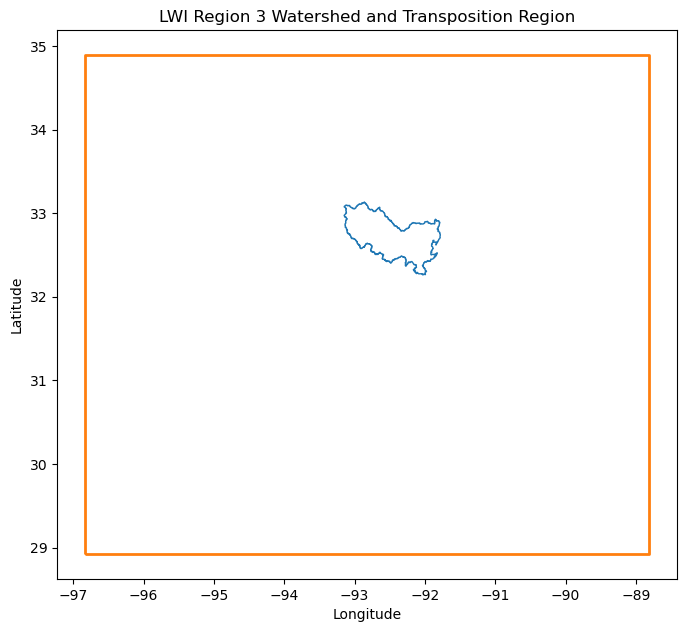

In [14]:
ax = transposition_gdf.boundary.plot(figsize=(8, 8), color="tab:orange", linewidth=2)
watershed_gdf.boundary.plot(ax=ax, color="tab:blue", linewidth=1)
ax.set_title("LWI Region 3 Watershed and Transposition Region")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude");

## Write StormHub Config

This keeps source files under `data/lwi-region3` and generated STAC catalog files under `catalogs/lwi-region3`.

In [15]:
config = {
    "watershed": {
        "id": "lwi-r3-huc12-domain",
        "geometry_file": str(WATERSHED_PATH),
        "description": "LWI Region 3 HUC12 watershed domain",
    },
    "transposition_region": {
        "id": "lwi-r3-transposition-domain",
        "geometry_file": str(TRANSPOSITION_REGION_PATH),
        "description": "LWI Region 3 transposition domain",
    },
}

CONFIG_PATH.write_text(json.dumps(config, indent=2), encoding="utf-8")
print(CONFIG_PATH)
config

c:\Users\ah5766\code\stormhub\catalogs\lwi-region3\lwi-r3-config.json


{'watershed': {'id': 'lwi-r3-huc12-domain',
  'geometry_file': 'c:\\Users\\ah5766\\code\\stormhub\\data\\lwi-region3\\lwi_r3_huc12_domain.json',
  'description': 'LWI Region 3 HUC12 watershed domain'},
 'transposition_region': {'id': 'lwi-r3-transposition-domain',
  'geometry_file': 'c:\\Users\\ah5766\\code\\stormhub\\data\\lwi-region3\\lwi_r3_climate_transposition_domain.json',
  'description': 'LWI Region 3 transposition domain'}}

## Create Base STAC Catalog

This creates `catalogs/lwi-region3/catalog.json` and the generated `hydro_domains` STAC items. It may access the AORC S3 dataset while creating the valid transposition-region item.

In [16]:
initialize_logger()

catalog = new_catalog(
    catalog_id=CATALOG_ID,
    config_file=str(CONFIG_PATH),
    local_directory=str(CATALOG_ROOT),
    catalog_description="LWI Region 3 storm catalog",
)

catalog.spm.catalog_file

2026-06-24 13:18:33,952 [INFO] Creating `transposition_region` item for catalog: lwi-region3
2026-06-24 13:18:33,958 [INFO] Creating `watershed` item for catalog: lwi-region3
2026-06-24 13:18:33,982 [INFO] Creating `valid_transposition_region` item for catalog: lwi-region3
2026-06-24 13:18:38,505 [INFO] Catalog has been created.


'c:\\Users\\ah5766\\code\\stormhub\\catalogs\\lwi-region3\\catalog.json'

In [17]:
sorted(p.relative_to(CATALOG_DIR) for p in CATALOG_DIR.rglob("*.json"))

[WindowsPath('48hr-events/1/1.json'),
 WindowsPath('48hr-events/collection.json'),
 WindowsPath('catalog.json'),
 WindowsPath('hydro_domains/lwi-r3-huc12-domain.json'),
 WindowsPath('hydro_domains/lwi-r3-transposition-domain.json'),
 WindowsPath('hydro_domains/lwi-r3-transposition-domain_valid.json'),
 WindowsPath('lwi-r3-config.json')]

## Serve The Catalog

Run this from a PowerShell terminal with the `stormhub` environment active:

```powershell
stormhub-server .\catalogs\lwi-region3 127.0.0.1 5000
```

Then open `http://localhost:5000/catalog.json` or use the STAC Browser link shown by the directory listing.